# Text-to-SQL with a Transformer built from scratch (WikiSQL)
Generative AI, Fall 2026, Assignment 2. Team: **<member 1>** and **<member 2>**.

An English question plus the column names of a table go in, a SQL query comes out. The encoder-decoder Transformer
from *Attention Is All You Need* is written by us in plain PyTorch (no `nn.Transformer`, no `nn.MultiheadAttention`, no pretrained weights).

**How to read this notebook:** it goes task by task. Every code cell that starts with `%%writefile` shows the code *and* saves it as a file of the GitHub repo,
so the notebook and the repo are the same code. Training and the long evaluation runs are already done and saved in Google Drive, so those cells
just load the saved checkpoint / results (the switches are `RUN_EVAL` and `RUN_TEST` below).

| Task | Section | Files |
|---|---|---|
| 1 Starter code | Task 1 | `starter/*`, `make_figures.py` |
| 2 Transformer | Task 2 | `model/attention.py`, `model/layers.py`, `model/transformer.py`, `common.py`, `checks.py` |
| 3 Training | Task 3 | `train.py` |
| 4 Decoding | Task 4 | `decode.py` |
| 5 Evaluation | Task 5 | `evaluate_model.py` |
| 6 Front end | Task 6 | `app/app.py` |

## 0. Setup

In [1]:
# GPU check, packages, Google Drive (checkpoints live there), folders, data
import os
!nvidia-smi -L || echo "no GPU here (fine for this notebook: training and evaluation results are loaded from Drive; a GPU is only needed to retrain or re-run the evaluation)"
!pip install -q sentencepiece records babel tqdm tabulate gradio matplotlib

from google.colab import drive
drive.mount('/content/drive')
DRIVE = "/content/drive/MyDrive/genai_a2"      # best.pt, last.pt, saved results
CKPT = f"{DRIVE}/best.pt"
os.makedirs(DRIVE, exist_ok=True)

os.makedirs("/content/text2sql", exist_ok=True)
%cd /content/text2sql
for d in ["starter", "model", "results", "app"]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists("WikiSQL"):
    !git clone -q https://github.com/salesforce/WikiSQL
    !cd WikiSQL && tar xjf data.tar.bz2

/bin/bash: line 1: nvidia-smi: command not found
no GPU here (fine for this notebook: training and evaluation results are loaded from Drive; a GPU is only needed to retrain or re-run the evaluation)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
Mounted at /content/drive
/content/text2sql


## Task 1 - Run the starter code
The given starter files (data prep, tokenizer, dataset, embeddings, check_starter) are written out below. Then we run them,
report the data statistics (Table 1) and plot the positional encoding.

In [2]:
%%writefile starter/data_prep.py
import json
from pathlib import Path

DATA_DIR = Path("WikiSQL/data")
AGG_OPS = ["", "MAX", "MIN", "COUNT", "SUM", "AVG"]
COND_OPS = ["=", ">", "<"]
MAX_COLS = 64  # column tokens <c0> ... <c63>


def load_split(split):
    """Return (examples, tables) for 'train', 'dev' or 'test'."""
    tables = {}
    with open(DATA_DIR / f"{split}.tables.jsonl", encoding="utf-8") as f:
        for line in f:
            t = json.loads(line)
            tables[t["id"]] = t
    with open(DATA_DIR / f"{split}.jsonl", encoding="utf-8") as f:
        examples = [json.loads(line) for line in f]
    return examples, tables


def encode_source(question, header):
    """question <sep> <c0> col name <c1> col name ..."""
    cols = " ".join(f"<c{i}> {name}" for i, name in enumerate(header))
    return f"{question.strip()} <sep> {cols}".lower()


def encode_target(sql):
    """{'sel','agg','conds'} -> 'select count <c3> where <c1> = kim manners'"""
    out = ["select"]
    if sql["agg"]:
        out.append(AGG_OPS[sql["agg"]].lower())
    out.append(f"<c{sql['sel']}>")

    for i, (col, op, val) in enumerate(sql["conds"]):
        out += [
            "where" if i == 0 else "and",
            f"<c{col}>",
            COND_OPS[op],
            str(val),
        ]
    return " ".join(out).lower()


def build_pairs(split):
    examples, tables = load_split(split)
    pairs = []
    for ex in examples:
        header = tables[ex["table_id"]]["header"]
        pairs.append({
            "table_id": ex["table_id"],
            "src": encode_source(ex["question"], header),
            "tgt": encode_target(ex["sql"]),
        })
    return pairs


if __name__ == "__main__":
    for split in ["train", "dev", "test"]:
        pairs = build_pairs(split)
        with open(
            f"{split}_pairs.jsonl", "w", encoding="utf-8"
        ) as f:
            for p in pairs:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")
        print(f"{split}: {len(pairs)} pairs ")
        print(pairs[0]["src"])
        print(pairs[0]["tgt"])

Writing starter/data_prep.py


In [3]:
%%writefile starter/tokenizer.py
import json
import sentencepiece as spm

from data_prep import MAX_COLS
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
SPECIAL = ["<sep>"] + [f"<c{i}>" for i in range(MAX_COLS)]


def read_pairs(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]


def train_tokenizer(train_path="train_pairs.jsonl", vocab_size=8000):
    pairs = read_pairs(train_path)
    with open("spm_corpus.txt", "w", encoding="utf-8") as f:
        for p in pairs:  # ONE shared vocabulary for
            f.write(p["src"] + "\n")  # source and target, as in
            f.write(p["tgt"] + "\n")  # the original Transformer
    spm.SentencePieceTrainer.train(
        input="spm_corpus.txt",
        model_prefix="sql_sp",
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=1.0,
        user_defined_symbols=SPECIAL,  # never split <sep>, <c0>, ...
        pad_id=PAD_ID,
        unk_id=UNK_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
    )
    return spm.SentencePieceProcessor(model_file="sql_sp.model")


if __name__ == "__main__":
    sp = train_tokenizer()
    p = read_pairs("dev_pairs.jsonl")[0]
    print(sp.encode(p["src"], out_type=str))
    print(sp.encode(p["tgt"], out_type=str))
    print(sp.decode(sp.encode(p["tgt"])) == p["tgt"])

Writing starter/tokenizer.py


In [4]:
%%writefile starter/dataset.py
import torch
from torch.utils.data import DataLoader, Dataset
from tokenizer import read_pairs, PAD_ID, BOS_ID, EOS_ID


class SQLDataset(Dataset):
    """Each item : ( source ids , target ids). Target = <s> ... </s >.

    train = True drops over - long pairs .
    train = False keeps EVERY row in file order ( needed for evaluation ) .
    """

    def __init__(self, path, sp, train=True, max_src=160, max_tgt=64):
        self.items, skipped = [], 0
        for p in read_pairs(path):
            src = sp.encode(p["src"]) + [EOS_ID]
            tgt = [BOS_ID] + sp.encode(p["tgt"]) + [EOS_ID]
            if train and (len(src) > max_src or len(tgt) > max_tgt):
                skipped += 1
                continue
            self.items.append((src, tgt))
        print(f"{path}: kept {len(self.items)}, skipped {skipped}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


def collate(batch):
    srcs, tgts = zip(*batch)
    S, T = max(map(len, srcs)), max(map(len, tgts))
    src = torch.full((len(batch), S), PAD_ID, dtype=torch.long)
    tgt = torch.full((len(batch), T), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src[i, : len(s)] = torch.tensor(s)
        tgt[i, : len(t)] = torch.tensor(t)
    return src, tgt  # (B, S), (B, T)


def make_loader(path, sp, train, batch_size=64):
    return DataLoader(
        SQLDataset(path, sp, train=train),
        batch_size=batch_size,
        shuffle=train,
        collate_fn=collate,
    )

Writing starter/dataset.py


In [5]:
%%writefile starter/embeddings.py
import math
import torch
import torch.nn as nn


class TokenEmbedding(nn.Module):
    """Section 3.4: embeddings are multiplied by sqrt(d_model).
    One instance is shared by the encoder, the decoder and
    (optionally) the final output projection.
    """

    def __init__(self, vocab_size, d_model, pad_id=0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.scale = math.sqrt(d_model)

    def forward(self, ids):  # (B, L) -> (B, L, d_model)
        return self.emb(ids) * self.scale


class PositionalEncoding(nn.Module):
    """Section 3.5: fixed sinusoidal encodings.
    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pos = torch.arange(max_len).unsqueeze(1)  # (L, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )  # (d/2,)
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, L, d)

    def forward(self, x):  # x: (B, L, d_model)
        return self.dropout(x + self.pe[:, : x.size(1)])


class InputLayer(nn.Module):
    """token ids -> scaled embedding + positional encoding -> dropout"""

    def __init__(self, token_emb, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.tok = token_emb
        self.pos = PositionalEncoding(d_model, max_len, dropout)

    def forward(self, ids):
        return self.pos(self.tok(ids))

Writing starter/embeddings.py


In [6]:
%%writefile starter/check_starter.py
import sentencepiece as spm

from tokenizer import PAD_ID
from dataset import make_loader
from embeddings import TokenEmbedding, InputLayer

sp = spm.SentencePieceProcessor(model_file="sql_sp.model")
train_dl = make_loader("train_pairs.jsonl", sp, train=True)
dev_dl = make_loader("dev_pairs.jsonl", sp, train=False)

src, tgt = next(iter(train_dl))
print("src", tuple(src.shape), "tgt", tuple(tgt.shape))

d_model = 256
shared = TokenEmbedding(sp.get_piece_size(), d_model, PAD_ID)
enc_in = InputLayer(shared, d_model)  # encoder input
dec_in = InputLayer(shared, d_model)  # decoder input (same weights)

x = enc_in(src)  # (B, S, 256) -> goes into YOUR encoder
y = dec_in(tgt[:, :-1])  # (B, T - 1, 256) -> goes into YOUR decoder
print("encoder input", tuple(x.shape), "decoder input", tuple(y.shape))

Writing starter/check_starter.py


In [7]:
# build the (source, target) text pairs, then train the shared BPE tokenizer (8000 pieces)
!python starter/data_prep.py
!python starter/tokenizer.py 2>&1 | grep -v -E "^(I0000|WARNING|trainer_spec|normalizer_spec|denormalizer_spec|\}|  )"
import shutil
if not os.path.exists(f"{DRIVE}/sql_sp.model"):      # keep a copy of the tokenizer next to the checkpoint
    shutil.copy("sql_sp.model", DRIVE)

train: 56355 pairs 
tell me what the notes are for south australia <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
select <c5> where <c3> = south australia
dev: 8421 pairs 
what position does the player who played for butler cc (ks) play? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c3> where <c5> = butler cc (ks)
test: 15878 pairs 
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross
['▁what', '▁position', '▁does', '▁the', '▁player', '▁who', '▁played', '▁for', '▁but', 'ler', '▁cc', '▁(', 'ks', ')', '▁play', '?', '▁', '<sep>', '▁', '<c0>', '▁player', '▁', '<c1>', '▁no', '.', '▁', '<c2>', '▁nationality', '▁', '<c3>', '▁position', '▁', '<c4>', '▁years', '▁in', '▁toronto', '▁', '<c5>', '▁school', '/', 'club', '▁team']
['▁select', '▁', 

In [8]:
# shapes check (should print src (64, S) tgt (64, T), encoder input (64, S, 256), decoder input (64, T-1, 256))
!python starter/check_starter.py

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
src (64, 91) tgt (64, 33)
encoder input (64, 91, 256) decoder input (64, 32, 256)


In [9]:
%%writefile make_figures.py
"""Figures + Table 1 that don't need the trained model:
PE heat-map, LR schedule, loss curves (needs results/history.json), Table 1 numbers.
Usage: python make_figures.py
"""
import json
import os
import sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), "starter"))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402

import sentencepiece as spm  # noqa: E402
from embeddings import PositionalEncoding  # noqa: E402
from tokenizer import read_pairs  # noqa: E402

os.makedirs("results", exist_ok=True)


def noam_lr(step, d_model=256, warmup=4000):
    """same schedule as train.py (paper eq. 3), copied here so this script needs no model code"""
    step = max(step, 1)
    return d_model ** -0.5 * min(step ** -0.5, step * warmup ** -1.5)


# --- positional encoding heat-map (first 100 positions x 256 dims)
pe = PositionalEncoding(256).pe[0, :100, :].numpy()
plt.figure(figsize=(9, 4))
plt.imshow(pe, aspect="auto", cmap="RdBu")
plt.colorbar(label="value")
plt.xlabel("dimension (0-255)")
plt.ylabel("position (0-99)")
plt.title("Positional encoding")
plt.savefig("results/pe_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()

# --- learning-rate schedule, first 20,000 steps
steps = list(range(1, 20001))
plt.figure(figsize=(7, 3.5))
plt.plot(steps, [noam_lr(s) for s in steps])
plt.axvline(4000, color="gray", linestyle="--", label="warmup = 4000")
plt.xlabel("step")
plt.ylabel("learning rate")
plt.title("LR schedule (first 20,000 steps)")
plt.legend()
plt.savefig("results/lr_schedule.png", dpi=150, bbox_inches="tight")
plt.close()

# --- training / dev loss per epoch
if os.path.exists("results/history.json"):
    h = json.load(open("results/history.json"))
    ep = [x["epoch"] for x in h]
    plt.figure(figsize=(7, 3.5))
    plt.plot(ep, [x["train_loss"] for x in h], marker="o", label="train")
    plt.plot(ep, [x["dev_loss"] for x in h], marker="o", label="dev")
    plt.xlabel("epoch")
    plt.ylabel("loss (label smoothing 0.1)")
    plt.title("Training and dev loss")
    plt.legend()
    plt.savefig("results/loss_curves.png", dpi=150, bbox_inches="tight")
    plt.close()
else:
    print("results/history.json not found, skipping loss curves")

# --- Table 1 (lengths include <s> and </s>, same counting as dataset.py)
sp = spm.SentencePieceProcessor(model_file="sql_sp.model")
table1 = {}
for split in ["train", "dev", "test"]:
    pairs = read_pairs(f"{split}_pairs.jsonl")
    sl = np.array([len(x) + 1 for x in sp.encode([p["src"] for p in pairs])])
    tl = np.array([len(x) + 2 for x in sp.encode([p["tgt"] for p in pairs])])
    too_long = int(((sl > 160) | (tl > 64)).sum())
    table1[split] = {"pairs": len(pairs),
                     "src_mean": round(float(sl.mean()), 1), "src_max": int(sl.max()),
                     "tgt_mean": round(float(tl.mean()), 1), "tgt_max": int(tl.max()),
                     # only train drops long pairs; dev/test keep every row for evaluation
                     "dropped": too_long if split == "train" else 0,
                     "longer_than_limit": too_long}
    print(split, table1[split])
json.dump(table1, open("results/table1.json", "w"), indent=1)
print("saved figures + results/table1.json")

Writing make_figures.py


results/history.json not found, skipping loss curves
train {'pairs': 56355, 'src_mean': 42.5, 'src_max': 222, 'tgt_mean': 14.8, 'tgt_max': 65, 'dropped': 19, 'longer_than_limit': 19}
dev {'pairs': 8421, 'src_mean': 42.5, 'src_max': 167, 'tgt_mean': 14.8, 'tgt_max': 44, 'dropped': 0, 'longer_than_limit': 1}
test {'pairs': 15878, 'src_mean': 42.7, 'src_max': 260, 'tgt_mean': 14.9, 'tgt_max': 46, 'dropped': 0, 'longer_than_limit': 4}
saved figures + results/table1.json


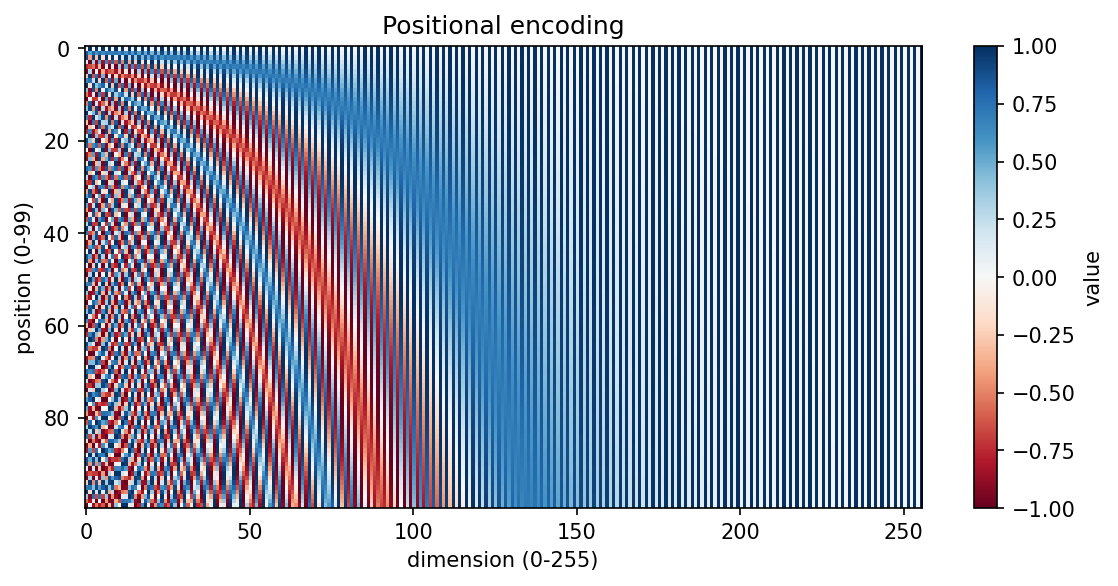

In [10]:
# Table 1 numbers + positional-encoding heat-map (+ LR schedule, loss curves once history.json exists)
!python make_figures.py
from IPython.display import Image, Markdown, display
display(Image("results/pe_heatmap.png"))

**Table 1 - Data** (lengths include `<s>` and `</s>`; only train drops over-long pairs, dev/test keep every row)

| | Train | Dev | Test |
|---|---|---|---|
| Pairs | 56,355 | 8,421 | 15,878 |
| Mean / max source length | 42.5 / 222 | 42.5 / 167 | 42.7 / 260 |
| Mean / max target length | 14.8 / 65 | 14.8 / 44 | 14.9 / 46 |
| Pairs dropped as too long | 19 | 0 | 0 |

**Positional encoding heat-map:** each row is a position and each column a dimension. The left dimensions change quickly from one position
to the next (fast sin/cos waves), the right dimensions change very slowly and look almost constant. Together the different frequencies give every
position its own pattern, which is how the model knows word order.

## Task 2 - The Transformer
d_model 256, 4 heads (d_k = d_v = 64), 3 encoder + 3 decoder layers, d_ff 1024, dropout 0.1, post-norm,
one weight matrix shared by the encoder embedding, decoder embedding and output layer.

In [11]:
%%writefile model/__init__.py
# makes model/ a package

Writing model/__init__.py


In [12]:
%%writefile model/attention.py
"""Scaled dot-product attention and multi-head attention (paper, section 3.2)."""
import math

import torch
import torch.nn as nn


def attention(Q, K, V, mask=None):
    """softmax(Q K^T / sqrt(d_k)) V

    mask: True/1 = position can be seen, False/0 = hidden. It only has to be
    broadcastable to (B, heads, Lq, Lk). Returns (output, attention weights).
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        # hidden positions get -inf so softmax turns them into exactly 0
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, h=4, dropout=0.1):
        super().__init__()
        assert d_model % h == 0, "d_model must be divisible by number of heads"
        self.h = h
        self.d_k = d_model // h  # 256 / 4 = 64
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        self.last_w = None  # kept so we can plot attention maps later

    def _split(self, x, lin):
        # (B, L, 256) -> (B, 4, L, 64): every head gets its own 64-dim slice
        B = x.size(0)
        return lin(x).view(B, -1, self.h, self.d_k).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        Q = self._split(q, self.W_q)
        K = self._split(k, self.W_k)
        V = self._split(v, self.W_v)
        out, w = attention(Q, K, V, mask)
        # glue the heads back together: (B, 4, L, 64) -> (B, L, 256)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.h * self.d_k)
        self.last_w = w.detach()
        return self.drop(self.W_o(out))

Writing model/attention.py


In [13]:
# Worked example (2 tokens, d_k = 2), same numbers we checked by hand:
# scores = QK^T/sqrt(2) -> softmax -> weights x V
import torch
from model.attention import attention

Q = torch.tensor([[1., 0.], [0., 1.]])
K = torch.tensor([[1., 0.], [1., 1.]])
V = torch.tensor([[1., 2.], [3., 4.]])
out, w = attention(Q, K, V)
print("weights:\n", w)          # [[0.5, 0.5], [0.3302, 0.6698]]
print("output:\n", out)         # [[2, 3], [2.3395, 3.3395]]  (by hand with rounded weights 0.3302 / 0.6698 you get 2.3396, 3.3396, just rounding)

# hide key 2 from query 1 -> that token gets weight exactly 0
mask = torch.tensor([[1, 0], [1, 1]])
out_m, w_m = attention(Q, K, V, mask)
print("masked weights:\n", w_m)   # row 1 -> [1, 0]
print("masked output row 1:", out_m[0])   # [1, 2]

weights:
 tensor([[0.5000, 0.5000],
        [0.3302, 0.6698]])
output:
 tensor([[2.0000, 3.0000],
        [2.3395, 3.3395]])
masked weights:
 tensor([[1.0000, 0.0000],
        [0.3302, 0.6698]])
masked output row 1: tensor([1., 2.])


In [14]:
%%writefile model/layers.py
"""Feed-forward, encoder layer and decoder layer (paper, sections 3.1 - 3.3)."""
import torch
import torch.nn as nn

from model.attention import MultiHeadAttention


class FeedForward(nn.Module):
    """FFN(x) = max(0, x W1 + b1) W2 + b2"""

    def __init__(self, d_model=256, d_ff=1024, dropout=0.1):
        super().__init__()
        self.l1 = nn.Linear(d_model, d_ff)
        self.l2 = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.l2(torch.relu(self.l1(x))))


class EncoderLayer(nn.Module):
    # post-norm like the paper: LayerNorm(x + Sublayer(x))
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, h, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.n1 = nn.LayerNorm(d_model)
        self.n2 = nn.LayerNorm(d_model)

    def forward(self, x, src_mask):
        x = self.n1(x + self.attn(x, x, x, src_mask))
        x = self.n2(x + self.ff(x))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h, dropout)
        self.cross_attn = MultiHeadAttention(d_model, h, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.n1 = nn.LayerNorm(d_model)
        self.n2 = nn.LayerNorm(d_model)
        self.n3 = nn.LayerNorm(d_model)

    def forward(self, y, enc_out, tgt_mask, src_mask):
        y = self.n1(y + self.self_attn(y, y, y, tgt_mask))               # masked self-attention
        y = self.n2(y + self.cross_attn(y, enc_out, enc_out, src_mask))  # look at the encoder
        y = self.n3(y + self.ff(y))
        return y

Writing model/layers.py


In [15]:
%%writefile model/transformer.py
"""Masks and the full encoder-decoder Transformer (paper, section 3)."""
import os
import sys

import torch
import torch.nn as nn

# the given starter files live in ../starter
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "starter"))
from embeddings import InputLayer, TokenEmbedding  # noqa: E402
from tokenizer import PAD_ID  # noqa: E402

from model.layers import DecoderLayer, EncoderLayer  # noqa: E402


def make_pad_mask(ids):
    """(B, L) -> (B, 1, 1, L). True = real token, False = <pad>."""
    return (ids != PAD_ID).unsqueeze(1).unsqueeze(2)


def make_causal_mask(T, device):
    """(1, 1, T, T) lower triangle: position t can only look at positions <= t."""
    return torch.tril(torch.ones(T, T, device=device)).bool().unsqueeze(0).unsqueeze(0)


class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, h=4, N=3, d_ff=1024, dropout=0.1):
        super().__init__()
        shared = TokenEmbedding(vocab_size, d_model, PAD_ID)
        self.enc_in = InputLayer(shared, d_model, dropout=dropout)
        self.dec_in = InputLayer(shared, d_model, dropout=dropout)  # same embedding weights
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.out = nn.Linear(d_model, vocab_size, bias=False)
        self.out.weight = shared.emb.weight  # output projection = embedding matrix (same tensor)

        # Xavier init like the paper's reference code, then put the <pad> row back to zero
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        with torch.no_grad():
            shared.emb.weight[PAD_ID].zero_()

    def encode(self, src):
        src_mask = make_pad_mask(src)
        x = self.enc_in(src)
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        return x, src_mask

    def decode(self, tgt_in, enc_out, src_mask):
        T = tgt_in.size(1)
        tgt_mask = make_pad_mask(tgt_in) & make_causal_mask(T, tgt_in.device)
        y = self.dec_in(tgt_in)
        for layer in self.dec_layers:
            y = layer(y, enc_out, tgt_mask, src_mask)
        return self.out(y)  # (B, T, vocab) logits

    def forward(self, src, tgt_in):
        enc_out, src_mask = self.encode(src)
        return self.decode(tgt_in, enc_out, src_mask)

Writing model/transformer.py


In [16]:
%%writefile common.py
"""Small helpers shared by the scripts. Run everything from the repo root."""
import os
import sys

HERE = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, HERE)
sys.path.insert(0, os.path.join(HERE, "starter"))

import sentencepiece as spm  # noqa: E402
import torch  # noqa: E402

from model.transformer import Transformer  # noqa: E402

device = "cuda" if torch.cuda.is_available() else "cpu"


def load_sp(path="sql_sp.model"):
    return spm.SentencePieceProcessor(model_file=path)


def load_model(ckpt_path, sp, dev=None):
    dev = dev or device
    model = Transformer(sp.get_piece_size()).to(dev)
    ck = torch.load(ckpt_path, map_location=dev)
    model.load_state_dict(ck["model"])
    model.eval()
    return model

Writing common.py


In [17]:
%%writefile checks.py
"""Correctness checks from section 3.2 (causal mask, padding mask, rows sum to 1, weight sharing).
Usage: python checks.py > results/checks.txt   (add --ckpt path/to/best.pt to test a trained model)
"""
import argparse

import torch

from common import device, load_model, load_sp
from dataset import make_loader
from model.transformer import Transformer
from tokenizer import PAD_ID

ap = argparse.ArgumentParser()
ap.add_argument("--ckpt", default=None)
args = ap.parse_args()

sp = load_sp()
V = sp.get_piece_size()
model = load_model(args.ckpt, sp) if args.ckpt else Transformer(V).to(device)
model.eval()  # dropout off, otherwise the comparisons are meaningless
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

src, tgt = next(iter(make_loader("dev_pairs.jsonl", sp, train=False, batch_size=64)))
src, tgt = src[:4].to(device), tgt[:4].to(device)
dec_in = tgt[:, :-1]

with torch.no_grad():
    base = model(src, dec_in)

    d2 = dec_in.clone()
    d2[:, -1] = (d2[:, -1] + 7) % V  # change only the last decoder input token
    out2 = model(src, d2)
    print("causal mask ok:", torch.allclose(base[:, :-1], out2[:, :-1], atol=1e-5))

    extra = torch.full((src.size(0), 5), PAD_ID, device=device)  # 5 extra <pad> on the source
    out3 = model(torch.cat([src, extra], dim=1), dec_in)
    print("padding mask ok:", torch.allclose(base, out3, atol=1e-5))

    for name, w in [("decoder cross-attn", model.dec_layers[-1].cross_attn.last_w),
                    ("encoder self-attn", model.enc_layers[-1].attn.last_w)]:
        s = w.sum(-1)
        print(f"{name} rows sum to 1:", torch.allclose(s, torch.ones_like(s), atol=1e-5))

print("weight sharing ok:", model.out.weight is model.enc_in.tok.emb.weight
      and model.enc_in.tok is model.dec_in.tok)

Writing checks.py


In [18]:
# Correctness checks (section 3.2). Run on a freshly initialised model; the same checks are repeated on the trained model in Task 3.
!python checks.py

trainable params: 7577600
dev_pairs.jsonl: kept 8421, skipped 0
causal mask ok: True
padding mask ok: True
decoder cross-attn rows sum to 1: True
encoder self-attn rows sum to 1: True
weight sharing ok: True


## Task 3 - Training
Teacher forcing (decoder input `tgt[:, :-1]`, target `tgt[:, 1:]`), cross-entropy with label smoothing 0.1 (ignoring `<pad>`),
Adam (0.9, 0.98, 1e-9), the paper's warmup schedule with 4000 steps, batch size 64, 20 epochs.
After each epoch the train loss, dev loss and lr are logged and the checkpoint with the lowest dev loss is saved to Drive.

If `last.pt` already exists in Drive the script resumes from it, so running this cell again after training has finished
only loads it and prints the summary.

In [19]:
%%writefile train.py
"""Task 3: train the Transformer from random init.

Colab example:
    python train.py --ckpt-dir /content/drive/MyDrive/genai_a2
If the session dies, run the same command again and it resumes from last.pt.
"""
import argparse
import json
import os
import time

import torch
import torch.nn as nn

from common import device, load_sp
from dataset import make_loader
from model.transformer import Transformer
from tokenizer import PAD_ID

D_MODEL, WARMUP = 256, 4000


def noam_lr(step, d_model=D_MODEL, warmup=WARMUP):
    """paper eq. 3: d_model^-0.5 * min(step^-0.5, step * warmup^-1.5)"""
    step = max(step, 1)  # avoid 0 ** -0.5
    return d_model ** -0.5 * min(step ** -0.5, step * warmup ** -1.5)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--epochs", type=int, default=20)
    ap.add_argument("--batch-size", type=int, default=64)
    ap.add_argument("--ckpt-dir", default="checkpoints")
    ap.add_argument("--max-steps-per-epoch", type=int, default=0, help="only for quick smoke tests")
    args = ap.parse_args()

    os.makedirs(args.ckpt_dir, exist_ok=True)
    os.makedirs("results", exist_ok=True)
    torch.manual_seed(42)

    sp = load_sp()
    V = sp.get_piece_size()
    model = Transformer(V).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("trainable params:", n_params)

    train_dl = make_loader("train_pairs.jsonl", sp, train=True, batch_size=args.batch_size)
    dev_dl = make_loader("dev_pairs.jsonl", sp, train=False, batch_size=args.batch_size)

    # label smoothing 0.1, <pad> is ignored
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
    opt = torch.optim.Adam(model.parameters(), lr=0.0, betas=(0.9, 0.98), eps=1e-9)

    last_path = os.path.join(args.ckpt_dir, "last.pt")
    best_path = os.path.join(args.ckpt_dir, "best.pt")
    start_epoch, step, best_dev, history, train_secs = 0, 0, float("inf"), [], 0.0

    if os.path.exists(last_path):  # resume after a disconnect
        ck = torch.load(last_path, map_location=device)
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["opt"])
        start_epoch, step = ck["epoch"], ck["step"]
        best_dev, history, train_secs = ck["best_dev"], ck["history"], ck["train_secs"]
        print(f"resumed from epoch {start_epoch}, step {step}")

    def run_loss(src, tgt):
        # teacher forcing: decoder input = tgt[:, :-1], target = tgt[:, 1:]
        logits = model(src, tgt[:, :-1])
        return criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))

    @torch.no_grad()
    def dev_loss():
        model.eval()
        tot, n = 0.0, 0
        for i, (src, tgt) in enumerate(dev_dl):
            if args.max_steps_per_epoch and i >= args.max_steps_per_epoch:
                break
            tot += run_loss(src.to(device), tgt.to(device)).item()
            n += 1
        return tot / n

    for epoch in range(start_epoch, args.epochs):
        model.train()
        t0, tot, n = time.time(), 0.0, 0
        for i, (src, tgt) in enumerate(train_dl):
            if args.max_steps_per_epoch and i >= args.max_steps_per_epoch:
                break
            src, tgt = src.to(device), tgt.to(device)
            step += 1
            lr = noam_lr(step)
            for g in opt.param_groups:
                g["lr"] = lr
            loss = run_loss(src, tgt)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()
            n += 1

        train_secs += time.time() - t0
        tr, dv = tot / n, dev_loss()
        history.append({"epoch": epoch + 1, "train_loss": tr, "dev_loss": dv, "lr": lr})
        print(f"epoch {epoch+1:2d} | train {tr:.4f} | dev {dv:.4f} | lr {lr:.6f} | {time.time()-t0:.0f}s")

        if dv < best_dev:  # keep the checkpoint with the lowest dev loss
            best_dev = dv
            torch.save({"model": model.state_dict(), "epoch": epoch + 1, "dev_loss": dv}, best_path)
            print("   ^ best so far, saved")

        torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch + 1,
                    "step": step, "best_dev": best_dev, "history": history,
                    "train_secs": train_secs}, last_path)
        json.dump(history, open("results/history.json", "w"), indent=1)

    json.dump(history, open("results/history.json", "w"), indent=1)  # also when resuming a finished run
    summary_path = "results/train_summary.json"
    if start_epoch >= args.epochs and os.path.exists(summary_path):
        # training was already finished before: keep the summary written by the original run,
        # it knows which GPU the training really used (this machine may be a different one)
        summary = json.load(open(summary_path))
    else:
        best_ep = min(history, key=lambda h: h["dev_loss"])["epoch"]
        gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
        summary = {"trainable_params": n_params, "epochs_trained": len(history), "best_epoch": best_ep,
                   "best_dev_loss": best_dev, "train_minutes": round(train_secs / 60, 1), "gpu": gpu}
        json.dump(summary, open(summary_path, "w"), indent=1)
    print(summary)


if __name__ == "__main__":
    main()

Writing train.py


In [20]:
# first run: 20 epochs (about 20 min on a T4). Re-running resumes; once finished it only prints the summary recorded by the original run.
# (bring back the saved summary/history from the original training run first)
!mkdir -p results && cp -f {DRIVE}/results_backup_final/train_summary.json {DRIVE}/results_backup_final/history.json results/ 2>/dev/null
!python train.py --ckpt-dir {DRIVE}

trainable params: 7577600
train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
resumed from epoch 20, step 17620
{'trainable_params': 7577600, 'epochs_trained': 20, 'best_epoch': 18, 'best_dev_loss': 1.4455, 'train_minutes': 19.8, 'gpu': 'Tesla T4'}


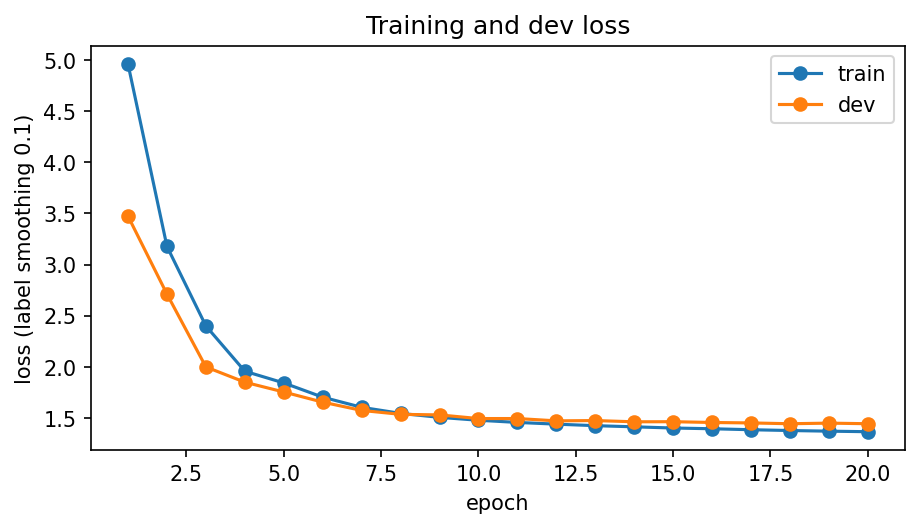

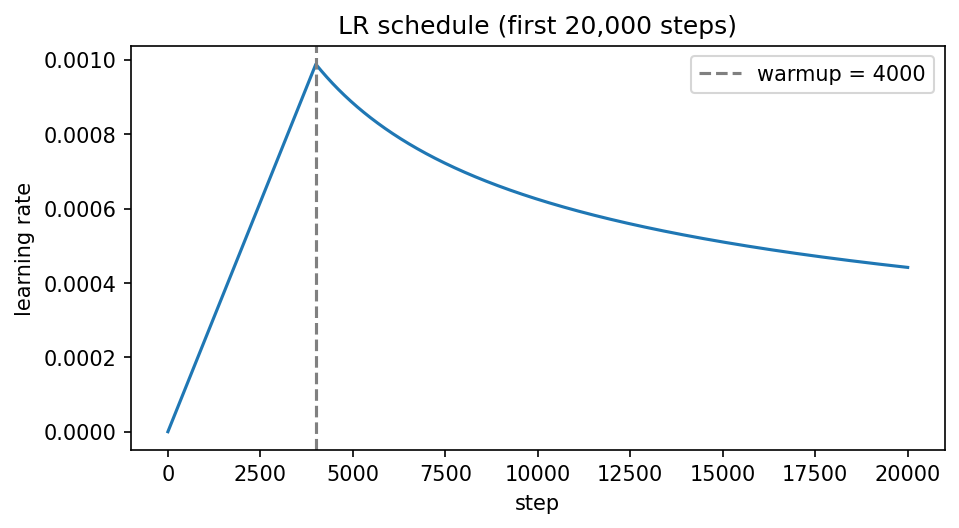

trainable params: 7577600
dev_pairs.jsonl: kept 8421, skipped 0
causal mask ok: True
padding mask ok: True
decoder cross-attn rows sum to 1: True
encoder self-attn rows sum to 1: True
weight sharing ok: True


In [21]:
# loss curves + LR schedule (first 20,000 steps), and the trained model through the same correctness checks
!python make_figures.py > /dev/null
display(Image("results/loss_curves.png"))
display(Image("results/lr_schedule.png"))
!python checks.py --ckpt {CKPT}

The learning rate rises linearly for 4000 steps (peak about 0.000988) and then decays as 1/sqrt(step). Train and dev loss go down together
(dev loss 1.4455 at the best epoch 18 of 20), no sign of overfitting. These losses include label smoothing, so they are not accuracies.

## Task 4 - Decoding and conversion to SQL
Greedy decoding and beam search (beam 4, stop at `</s>` or after 64 tokens), a parser from the generated text to WikiSQL's
`{"sel", "agg", "conds"}` format, and a function that prints readable SQL with the real column names.

In [22]:
%%writefile decode.py
"""Task 4: greedy decoding, beam search, parser (text -> WikiSQL dict), readable SQL."""
import re

import common  # noqa: F401  (puts starter/ on sys.path)

import torch

from data_prep import AGG_OPS, COND_OPS, MAX_COLS, encode_source
from tokenizer import BOS_ID, EOS_ID

MAX_LEN = 64  # max generated tokens


# ----------------------------------------------------------------- decoding
@torch.no_grad()
def greedy_decode(model, src, max_len=MAX_LEN):
    """src: (B, S) -> list of B lists of token ids (without <s>, without </s>)."""
    model.eval()
    B = src.size(0)
    enc_out, src_mask = model.encode(src)
    ys = torch.full((B, 1), BOS_ID, dtype=torch.long, device=src.device)
    done = torch.zeros(B, dtype=torch.bool, device=src.device)
    for _ in range(max_len):
        logits = model.decode(ys, enc_out, src_mask)
        nxt = logits[:, -1].argmax(-1)
        nxt = torch.where(done, torch.zeros_like(nxt), nxt)  # finished rows just get <pad>
        ys = torch.cat([ys, nxt.unsqueeze(1)], dim=1)
        done = done | (nxt == EOS_ID)
        if done.all():
            break
    out = []
    for row in ys[:, 1:].tolist():
        toks = []
        for t in row:
            if t == EOS_ID or t == 0:
                break
            toks.append(t)
        out.append(toks)
    return out


@torch.no_grad()
def beam_search(model, src, beam=4, max_len=MAX_LEN):
    """src: (1, S). Returns the best hypothesis as a list of ids (no <s>, no </s>).
    Hypotheses are ranked by average log-prob per token (simple length normalisation)."""
    model.eval()
    enc_out, src_mask = model.encode(src)
    beams = [([BOS_ID], 0.0)]
    finished = []
    for _ in range(max_len):
        seqs = torch.tensor([b[0] for b in beams], device=src.device)
        k = seqs.size(0)
        logits = model.decode(seqs, enc_out.expand(k, -1, -1), src_mask.expand(k, -1, -1, -1))
        logp = torch.log_softmax(logits[:, -1], dim=-1)
        cands = []
        for i, (toks, sc) in enumerate(beams):
            top = logp[i].topk(beam)
            for lp, idx in zip(top.values.tolist(), top.indices.tolist()):
                cands.append((toks + [idx], sc + lp))
        cands.sort(key=lambda c: c[1], reverse=True)
        beams = []
        for toks, sc in cands:
            if toks[-1] == EOS_ID:
                finished.append((toks, sc))
            else:
                beams.append((toks, sc))
            if len(beams) == beam:
                break
        if not beams or len(finished) >= beam:
            break
    pool = finished if finished else beams
    best = max(pool, key=lambda c: c[1] / len(c[0]))
    toks = best[0][1:]
    return [t for t in toks if t != EOS_ID]


# ------------------------------------------------------------------ parsing
_HEAD = re.compile(r"^select\s+(?:(max|min|count|sum|avg)\s+)?<c(\d+)>\s*(.*)$", re.S)
_COND = re.compile(r"^<c(\d+)>\s*([=<>])\s*(.*)$", re.S)
_SPLIT = re.compile(r"\s+and\s+(?=<c\d+>\s*[=<>])")


def parse_query(text):
    """'select count <c3> where <c1> = kim manners' -> {'sel':3,'agg':3,'conds':[[1,0,'kim manners']]}
    Returns None if the string does not follow the grammar."""
    m = _HEAD.match(text.strip())
    if not m:
        return None
    agg_name, sel, rest = m.groups()
    agg = AGG_OPS.index(agg_name.upper()) if agg_name else 0
    conds = []
    rest = rest.strip()
    if rest:
        if not rest.startswith("where "):
            return None
        for part in _SPLIT.split(rest[len("where "):]):
            m2 = _COND.match(part.strip())
            if not m2:
                return None
            col, op, val = m2.groups()
            conds.append([int(col), COND_OPS.index(op), val.strip()])
    return {"sel": int(sel), "agg": agg, "conds": conds}


def ids_to_query(sp, ids, n_cols=None):
    """ids -> parsed query dict, or None when parsing fails.
    If n_cols is given, column tokens that point past the table also count as a parse failure."""
    q = parse_query(sp.decode(ids))
    if q is None:
        return None
    if n_cols is not None:
        cols = [q["sel"]] + [c[0] for c in q["conds"]]
        if any(c >= n_cols for c in cols):
            return None
    return q


# --------------------------------------------------------------- readable SQL
def to_readable_sql(q, header):
    """parsed query + real column names -> SELECT ... FROM table WHERE ..."""
    def col(i):
        return header[i] if 0 <= i < len(header) else f"<c{i}>"
    sel = col(q["sel"])
    if q["agg"]:
        sel = f"{AGG_OPS[q['agg']]}({sel})"
    sql = f"SELECT {sel} FROM table"
    if q["conds"]:
        sql += " WHERE " + " AND ".join(
            f"{col(c)} {COND_OPS[o]} '{v}'" for c, o, v in q["conds"])
    return sql


# --------------------------------------------- single question (front end)
def translate(model, sp, question, header, decoding="beam", device="cpu"):
    """question + list of column names -> (readable SQL or None, raw model output string)"""
    if len(header) > MAX_COLS:
        raise ValueError(f"at most {MAX_COLS} columns are supported")
    ids = sp.encode(encode_source(question, header)) + [EOS_ID]
    src = torch.tensor([ids], device=device)
    out = beam_search(model, src) if decoding == "beam" else greedy_decode(model, src)[0]
    raw = sp.decode(out)
    q = ids_to_query(sp, out, n_cols=len(header))
    return (to_readable_sql(q, header) if q else None), raw

Writing decode.py


In [23]:
# three dev questions: gold SQL vs greedy vs beam, with real column names
import torch
from common import load_model, load_sp, device
from decode import greedy_decode, beam_search, ids_to_query, to_readable_sql
from data_prep import load_split
from tokenizer import read_pairs, EOS_ID

sp = load_sp()
model = load_model(CKPT, sp)
examples, tables = load_split("dev")
pairs = read_pairs("dev_pairs.jsonl")

for i in [1, 2, 3]:
    src = torch.tensor([sp.encode(pairs[i]["src"]) + [EOS_ID]], device=device)
    header = tables[examples[i]["table_id"]]["header"]
    print("Q     :", examples[i]["question"])
    print("gold  :", to_readable_sql(examples[i]["sql"], header))
    for name, ids in [("greedy", greedy_decode(model, src)[0]), ("beam", beam_search(model, src))]:
        q = ids_to_query(sp, ids, n_cols=len(header))
        print(f"{name:6}:", to_readable_sql(q, header) if q else "PARSE FAILURE")
    print()

Q     : How many schools did player number 3 play at?
gold  : SELECT COUNT(School/Club Team) FROM table WHERE No. = '3'
greedy: SELECT COUNT(School/Club Team) FROM table WHERE No. = '3'
beam  : SELECT COUNT(School/Club Team) FROM table WHERE No. = '3'

Q     : What school did player number 21 play for?
gold  : SELECT School/Club Team FROM table WHERE No. = '21'
greedy: SELECT School/Club Team FROM table WHERE No. = '21'
beam  : SELECT School/Club Team FROM table WHERE No. = '21'

Q     : Who is the player that wears number 42?
gold  : SELECT Player FROM table WHERE No. = '42'
greedy: SELECT Player FROM table WHERE No. = '42'
beam  : SELECT Player FROM table WHERE No. = '42'



## Task 5 - Evaluation and analysis
`evaluate_model.py` writes one prediction line per example (in file order), runs the **official** WikiSQL evaluator, computes the parse-failure rate and
component accuracy, plots the cross-attention map and writes `samples.md`. It also does the gold round-trip check
(gold dev targets -> our parser -> official evaluator).

The full runs take a while (dev greedy + beam about 11 minutes, test beam about 22 minutes), so they were run once and the results are saved in Drive.
Set `RUN_EVAL` / `RUN_TEST` to `True` only if you really want to run them again. **The test set was run exactly once, with beam search, after the
decoding choice was made on dev.**

In [24]:
%%writefile evaluate_model.py
"""Task 5: predictions, official evaluator, component accuracy, attention map, samples.

    python evaluate_model.py dev  --ckpt checkpoints/best.pt            # greedy + beam + everything on dev
    python evaluate_model.py test --ckpt checkpoints/best.pt --decode beam   # run ONCE at the very end
Add --limit 200 for a quick smoke test (then delete results/ files and run the real thing).
"""
import argparse
import json
import os
import re
import subprocess
import sys
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
import torch  # noqa: E402
from tqdm import tqdm  # noqa: E402

from common import device, load_model, load_sp  # noqa: E402
from data_prep import load_split  # noqa: E402
from decode import beam_search, greedy_decode, ids_to_query, parse_query, to_readable_sql  # noqa: E402
from tokenizer import BOS_ID, EOS_ID, PAD_ID, read_pairs  # noqa: E402

WIKISQL = "WikiSQL"
RES = "results"


# --------------------------------------------------------------- predictions
def predict(model, sp, split, decoding, limit=0, bs=64):
    """Returns one list of token ids per example, in the same order as {split}.jsonl."""
    pairs = read_pairs(f"{split}_pairs.jsonl")
    if limit:
        pairs = pairs[:limit]
    srcs = [sp.encode(p["src"]) + [EOS_ID] for p in pairs]
    out = []
    if decoding == "greedy":
        for i in tqdm(range(0, len(srcs), bs), desc=f"{split} greedy"):
            chunk = srcs[i:i + bs]
            S = max(map(len, chunk))
            batch = torch.full((len(chunk), S), PAD_ID, dtype=torch.long)
            for j, s in enumerate(chunk):
                batch[j, :len(s)] = torch.tensor(s)
            out += greedy_decode(model, batch.to(device))
    else:
        for s in tqdm(srcs, desc=f"{split} beam(4)"):
            out.append(beam_search(model, torch.tensor([s], device=device), beam=4))
    return out


def to_queries(sp, id_lists, examples, tables):
    qs = []
    for ids, ex in zip(id_lists, examples):
        n_cols = len(tables[ex["table_id"]]["header"])
        qs.append(ids_to_query(sp, ids, n_cols=n_cols))
    return qs


def write_predictions(path, queries):
    with open(path, "w", encoding="utf-8") as f:
        for q in queries:  # one line per example, never skip one
            f.write(json.dumps({"query": q} if q is not None else {"error": "parse"}) + "\n")


def official_eval(split, pred_path):
    r = subprocess.run([sys.executable, "evaluate.py", f"data/{split}.jsonl", f"data/{split}.db",
                        os.path.abspath(pred_path)], cwd=WIKISQL, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-2000:])
    d = json.loads(r.stdout[r.stdout.index("{"):])
    return round(100 * d["lf_accuracy"], 2), round(100 * d["ex_accuracy"], 2)


# ---------------------------------------------------------- component accuracy
def cond_set(conds):
    return {(int(c), int(o), str(v).lower()) for c, o, v in conds}


def component_accuracy(queries, examples):
    n = len(queries)
    sel = agg = where = 0
    for q, ex in zip(queries, examples):
        g = ex["sql"]
        if q is None:
            continue
        sel += q["sel"] == g["sel"]
        agg += q["agg"] == g["agg"]
        where += cond_set(q["conds"]) == cond_set(g["conds"])
    return {"sel": round(100 * sel / n, 2), "agg": round(100 * agg / n, 2), "where": round(100 * where / n, 2)}


def failure_type(q, g):
    if q is None:
        return "parse failure"
    if q["sel"] != g["sel"]:
        return "wrong select column"
    if q["agg"] != g["agg"]:
        return "wrong aggregation"
    pc, gc = cond_set(q["conds"]), cond_set(g["conds"])
    if pc == gc:
        return "correct"
    if len(pc) < len(gc):
        return "missing condition"
    if len(pc) > len(gc):
        return "extra condition"
    if {c for c, _, _ in pc} != {c for c, _, _ in gc}:
        return "wrong condition column"
    return "wrong value or operator"


# ----------------------------------------------------------------- samples.md
def write_samples(queries, examples, tables, decoding, path=f"{RES}/samples.md"):
    right, wrong, seen = [], [], set()
    rows = [(i, failure_type(q, ex["sql"])) for i, (q, ex) in enumerate(zip(queries, examples))]
    right = [i for i, t in rows if t == "correct"][:5]
    bad = [(i, t) for i, t in rows if t != "correct"]
    for i, t in bad:  # prefer different failure types
        if t not in seen and len(wrong) < 5:
            wrong.append((i, t))
            seen.add(t)
    for i, t in bad:
        if len(wrong) < 5 and (i, t) not in wrong:
            wrong.append((i, t))

    def block(i, tag):
        ex = examples[i]
        header = tables[ex["table_id"]]["header"]
        q = queries[i]
        return (f"**Question:** {ex['question']}\n\n"
                f"- Gold: `{to_readable_sql(ex['sql'], header)}`\n"
                f"- Ours ({decoding}): `{to_readable_sql(q, header) if q else 'PARSE FAILURE'}`\n"
                f"- Verdict: {tag}\n")

    with open(path, "w", encoding="utf-8") as f:
        f.write(f"# Qualitative samples (dev, {decoding})\n\nValues are lower-cased because the model works on lower-cased text.\n\n## Correct\n\n")
        for k, i in enumerate(right, 1):
            f.write(f"### {k}\n" + block(i, "correct") + "\n")
        f.write("## Wrong\n\n")
        for k, (i, t) in enumerate(wrong, 1):
            f.write(f"### {k}\n" + block(i, t) + "\n")


# -------------------------------------------------------------- attention map
def source_columns(pieces):
    """for every source piece, which column (0,1,2..) it belongs to (None before the first <cK>)."""
    col, out = None, []
    for p in pieces:
        m = re.fullmatch(r"<c(\d+)>", p)
        if m:
            col = int(m.group(1))
        out.append(col)
    return out


def cross_attention(model, sp, pair, gen_ids):
    src_ids = sp.encode(pair["src"]) + [EOS_ID]
    gen = gen_ids + [EOS_ID]
    dec_in = [BOS_ID] + gen[:-1]  # row i of the map = the step that produced gen[i]
    with torch.no_grad():
        model(torch.tensor([src_ids], device=device), torch.tensor([dec_in], device=device))
    w = model.dec_layers[-1].cross_attn.last_w[0].mean(0).cpu().numpy()  # average over heads: (T, S)
    return w, [sp.id_to_piece(i) for i in src_ids], [sp.id_to_piece(i) for i in gen]


def attention_report(model, sp, pairs, id_lists, idx, n_stat=200):
    w, xs, ys = cross_attention(model, sp, pairs[idx], id_lists[idx])
    fig, ax = plt.subplots(figsize=(max(8, 0.28 * len(xs)), max(3, 0.35 * len(ys))))
    im = ax.imshow(w, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(xs, rotation=90, fontsize=7)
    ax.set_yticks(range(len(ys)))
    ax.set_yticklabels(ys, fontsize=8)
    ax.set_xlabel("source tokens")
    ax.set_ylabel("generated tokens")
    ax.set_title(f"Decoder cross-attention, last layer (mean over heads), dev example {idx}")
    fig.colorbar(im)
    fig.savefig(f"{RES}/attention_map.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    lines = [f"dev example {idx}: {pairs[idx]['src']}", ""]
    cols = source_columns(xs)
    for t, y in enumerate(ys):
        if re.fullmatch(r"<c\d+>", y):
            pos = int(w[t].argmax())
            ok = cols[pos] == int(y[2:-1])
            lines.append(f"generated {y} -> most attended source token: {xs[pos]} (belongs to column {cols[pos]}) match={ok}")
    # same check over the first n_stat examples: does a generated <cK> attend inside column K's span?
    hit = tot = 0
    for j in range(min(n_stat, len(pairs))):
        w_j, xs_j, ys_j = cross_attention(model, sp, pairs[j], id_lists[j])
        cj = source_columns(xs_j)
        for t, y in enumerate(ys_j):
            if re.fullmatch(r"<c\d+>", y):
                tot += 1
                hit += cj[int(w_j[t].argmax())] == int(y[2:-1])
    lines += ["", f"over the first {min(n_stat, len(pairs))} dev examples: {hit}/{tot} generated column tokens "
                  f"({100 * hit / max(tot, 1):.1f}%) have their strongest attention inside the matching source column"]
    open(f"{RES}/attention_check.txt", "w").write("\n".join(lines))
    print("\n".join(lines))


# ------------------------------------------------------------------ tables
def load_metrics():
    p = f"{RES}/metrics.json"
    return json.load(open(p)) if os.path.exists(p) else {}


def save_metrics(m):
    json.dump(m, open(f"{RES}/metrics.json", "w"), indent=1)
    make_tables(m)


def make_tables(m):
    L = []
    if os.path.exists(f"{RES}/table1.json"):
        t = json.load(open(f"{RES}/table1.json"))
        L += ["## Table 1 - Data (lengths include <s> and </s>)", "",
              "| | Train | Dev | Test |", "|---|---|---|---|",
              "| Pairs | " + " | ".join(str(t[s]["pairs"]) for s in ["train", "dev", "test"]) + " |",
              "| Mean / max source length | " + " | ".join(f"{t[s]['src_mean']} / {t[s]['src_max']}" for s in ["train", "dev", "test"]) + " |",
              "| Mean / max target length | " + " | ".join(f"{t[s]['tgt_mean']} / {t[s]['tgt_max']}" for s in ["train", "dev", "test"]) + " |",
              "| Pairs dropped as too long | " + " | ".join(str(t[s]["dropped"]) for s in ["train", "dev", "test"]) + " |", ""]
    if os.path.exists(f"{RES}/train_summary.json"):
        s = json.load(open(f"{RES}/train_summary.json"))
        L += ["## Table 2 - Model and training", "",
              f"- Trainable parameters: {s['trainable_params']:,}",
              f"- Epochs trained / best epoch: {s['epochs_trained']} / {s['best_epoch']}",
              f"- Best dev loss: {s['best_dev_loss']:.4f}",
              f"- Training time and GPU: {s['train_minutes']} min on {s['gpu']}", ""]
    L += ["## Table 3 - Official metrics", "", "| Split | Decoding | Logical form (%) | Execution (%) | Parse failures (%) |", "|---|---|---|---|---|"]
    for key in ["dev_greedy", "dev_beam", "test_greedy", "test_beam"]:
        if key in m:
            r = m[key]
            sp_, dec = key.split("_")
            L.append(f"| {sp_.capitalize()} | {dec} | {r['lf']} | {r['ex']} | {r['parse_fail']} |")
    L += [""]
    for k, r in m.items():
        if k.startswith("component_"):
            L += [f"## Table 4 - Component accuracy (dev, {k.split('_')[1]})", "",
                  f"- sel column correct: {r['sel']}%", f"- agg correct: {r['agg']}%", f"- WHERE clause correct: {r['where']}%", ""]
    if "gold_roundtrip" in m:
        g = m["gold_roundtrip"]
        L += ["## Gold round-trip (dev gold targets -> our parser -> official evaluator)", "",
              f"- Logical form {g['lf']}%, execution {g['ex']}%, parse failures {g['parse_fail']}%", ""]
    open(f"{RES}/tables.md", "w").write("\n".join(L))


# -------------------------------------------------------------------- main
def run_split(model, sp, split, decoding, limit, m):
    examples, tables = load_split(split)
    if limit:
        examples = examples[:limit]
    t0 = time.time()
    ids = predict(model, sp, split, decoding, limit)
    qs = to_queries(sp, ids, examples, tables)
    path = f"{RES}/{split}_{decoding}.jsonl"
    write_predictions(path, qs)
    lf, ex = official_eval(split, path)
    pf = round(100 * sum(q is None for q in qs) / len(qs), 2)
    m[f"{split}_{decoding}"] = {"lf": lf, "ex": ex, "parse_fail": pf, "n": len(qs)}
    print(f"[{split} {decoding}] logical form {lf}% | execution {ex}% | parse failures {pf}% | {time.time()-t0:.0f}s")
    return ids, qs, examples, tables


def gold_roundtrip(sp, limit, m):
    examples, tables = load_split("dev")
    pairs = read_pairs("dev_pairs.jsonl")
    if limit:
        examples, pairs = examples[:limit], pairs[:limit]
    qs = [parse_query(p["tgt"]) for p in pairs]  # gold target text -> parser
    write_predictions(f"{RES}/dev_gold_roundtrip.jsonl", qs)
    lf, ex = official_eval("dev", f"{RES}/dev_gold_roundtrip.jsonl")
    pf = round(100 * sum(q is None for q in qs) / len(qs), 2)
    m["gold_roundtrip"] = {"lf": lf, "ex": ex, "parse_fail": pf}
    print(f"[gold round-trip] logical form {lf}% | execution {ex}% | parse failures {pf}%   (execution must be > 99%)")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("split", choices=["dev", "test"])
    ap.add_argument("--ckpt", default="checkpoints/best.pt")
    ap.add_argument("--decode", choices=["greedy", "beam"], default="beam", help="only used for test")
    ap.add_argument("--limit", type=int, default=0)
    args = ap.parse_args()
    os.makedirs(RES, exist_ok=True)

    sp = load_sp()
    model = load_model(args.ckpt, sp)
    m = load_metrics()

    if args.split == "test":
        run_split(model, sp, "test", args.decode, args.limit, m)  # test set: once, final decoding choice
        save_metrics(m)
        return

    gold_roundtrip(sp, args.limit, m)
    results = {}
    for dec in ["greedy", "beam"]:
        results[dec] = run_split(model, sp, "dev", dec, args.limit, m)
        m[f"component_{dec}"] = component_accuracy(results[dec][1], results[dec][2])
        print(f"[dev {dec}] components:", m[f"component_{dec}"])
        save_metrics(m)

    best = "beam" if m["dev_beam"]["ex"] >= m["dev_greedy"]["ex"] else "greedy"
    print("better decoding on dev (by execution accuracy):", best)
    ids, qs, examples, tables = results[best]
    write_samples(qs, examples, tables, best)
    attention_report(model, sp, read_pairs("dev_pairs.jsonl")[:len(ids)], ids, idx=0)
    save_metrics(m)


if __name__ == "__main__":
    main()

Writing evaluate_model.py


In [25]:
RUN_EVAL = False      # True = recompute everything on dev (~11 min)
if RUN_EVAL:
    !python evaluate_model.py dev --ckpt {CKPT}
else:
    !cp -r {DRIVE}/results_backup_final/. results/     # load the saved dev + test results

In [26]:
RUN_TEST = False      # the test set is meant to be used ONCE; this was already done (beam), see Table 3
if RUN_TEST:
    !python evaluate_model.py test --ckpt {CKPT} --decode beam

In [27]:
# Tables 1-4 and the gold round-trip
display(Markdown(open("results/tables.md").read()))

## Table 1 - Data (lengths include <s> and </s>)

| | Train | Dev | Test |
|---|---|---|---|
| Pairs | 56355 | 8421 | 15878 |
| Mean / max source length | 42.5 / 222 | 42.5 / 167 | 42.7 / 260 |
| Mean / max target length | 14.8 / 65 | 14.8 / 44 | 14.9 / 46 |
| Pairs dropped as too long | 19 | 0 | 0 |

## Table 2 - Model and training

- Trainable parameters: 7,577,600
- Epochs trained / best epoch: 20 / 18
- Best dev loss: 1.4455
- Training time and GPU: 19.8 min on Tesla T4

## Table 3 - Official metrics

| Split | Decoding | Logical form (%) | Execution (%) | Parse failures (%) |
|---|---|---|---|---|
| Dev | greedy | 65.29 | 71.56 | 0.0 |
| Dev | beam | 65.36 | 71.61 | 0.01 |
| Test | beam | 65.05 | 71.39 | 0.09 |

## Table 4 - Component accuracy (dev, greedy)

- sel column correct: 93.4%
- agg correct: 89.76%
- WHERE clause correct: 75.19%

## Table 4 - Component accuracy (dev, beam)

- sel column correct: 93.47%
- agg correct: 89.75%
- WHERE clause correct: 75.37%

## Gold round-trip (dev gold targets -> our parser -> official evaluator)

- Logical form 100.0%, execution 100.0%, parse failures 0.0%


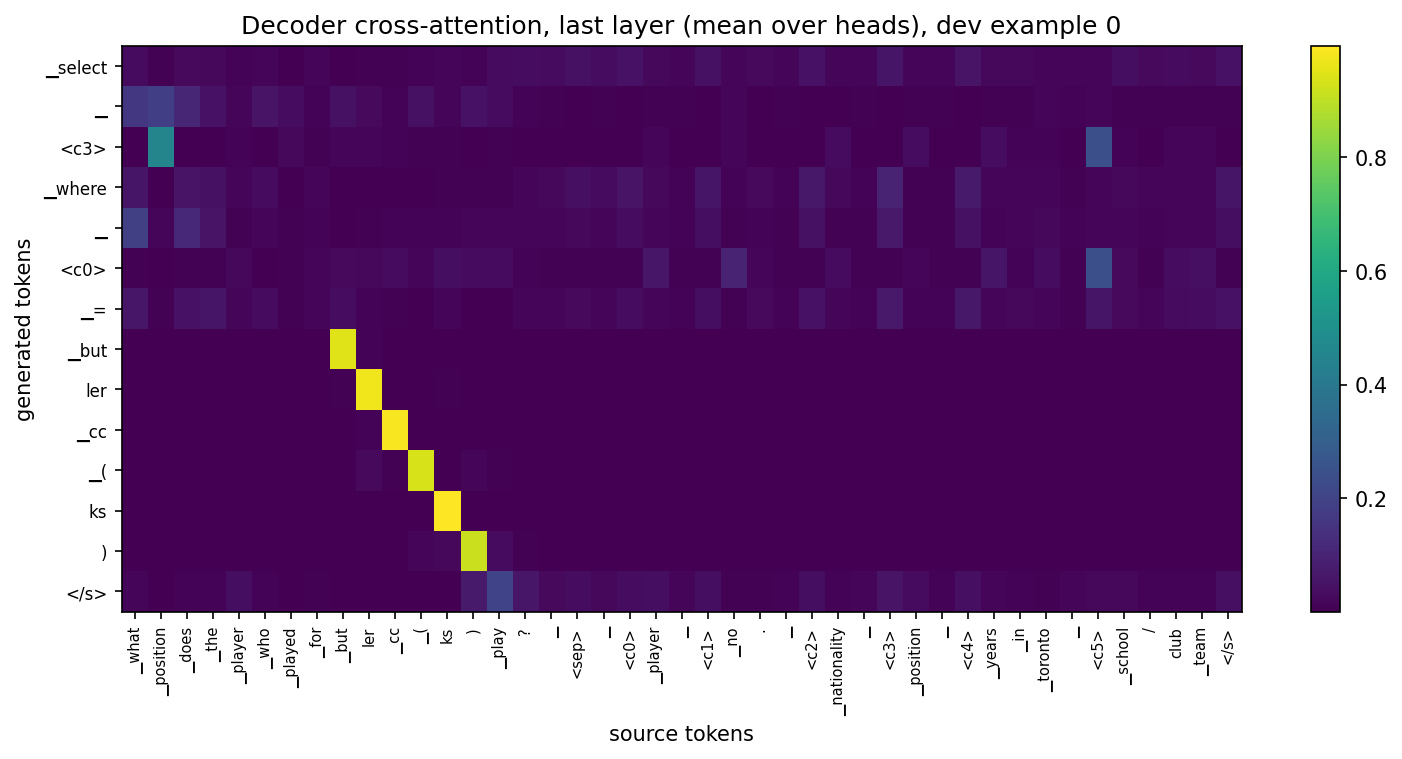

dev example 0: what position does the player who played for butler cc (ks) play? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team

generated <c3> -> most attended source token: ▁position (belongs to column None) match=False
generated <c0> -> most attended source token: <c5> (belongs to column 5) match=False

over the first 200 dev examples: 48/422 generated column tokens (11.4%) have their strongest attention inside the matching source column


In [28]:
# cross-attention map of the last decoder layer (mean over heads) for dev example 0
display(Image("results/attention_map.png"))
print(open("results/attention_check.txt").read())

In [29]:
# 10 dev examples: 5 correct, 5 wrong (also in results/samples.md)
display(Markdown(open("results/samples.md").read()))

# Qualitative samples (dev, beam)

Values are lower-cased because the model works on lower-cased text.

## Correct

### 1
**Question:** How many schools did player number 3 play at?

- Gold: `SELECT COUNT(School/Club Team) FROM table WHERE No. = '3'`
- Ours (beam): `SELECT COUNT(School/Club Team) FROM table WHERE No. = '3'`
- Verdict: correct

### 2
**Question:** What school did player number 21 play for?

- Gold: `SELECT School/Club Team FROM table WHERE No. = '21'`
- Ours (beam): `SELECT School/Club Team FROM table WHERE No. = '21'`
- Verdict: correct

### 3
**Question:** Who is the player that wears number 42?

- Gold: `SELECT Player FROM table WHERE No. = '42'`
- Ours (beam): `SELECT Player FROM table WHERE No. = '42'`
- Verdict: correct

### 4
**Question:** What player played guard for toronto in 1996-97?

- Gold: `SELECT Player FROM table WHERE Position = 'Guard' AND Years in Toronto = '1996-97'`
- Ours (beam): `SELECT Player FROM table WHERE Position = 'guard' AND Years in Toronto = '1996-97'`
- Verdict: correct

### 5
**Question:** Who are all of the players on the Westchester High School club team?

- Gold: `SELECT Player FROM table WHERE School/Club Team = 'Westchester High School'`
- Ours (beam): `SELECT Player FROM table WHERE School/Club Team = 'westchester high school'`
- Verdict: correct

## Wrong

### 1
**Question:** What position does the player who played for butler cc (ks) play?

- Gold: `SELECT Position FROM table WHERE School/Club Team = 'Butler CC (KS)'`
- Ours (beam): `SELECT Position FROM table WHERE Player = 'butler cc (ks)'`
- Verdict: wrong condition column

### 2
**Question:** What is the English name of the country whose official native language is Dutch Papiamento?

- Gold: `SELECT Country ( exonym ) FROM table WHERE Official or native language(s) (alphabet/script) = 'Dutch Papiamento'`
- Ours (beam): `SELECT Official or native language(s) (alphabet/script) FROM table WHERE Country ( exonym ) = 'dutch papiamento'`
- Verdict: wrong select column

### 3
**Question:** Name the minimum tiesplayed for 6 years

- Gold: `SELECT MIN(Ties played) FROM table WHERE Years played = '6'`
- Ours (beam): `SELECT MIN(Ties played) FROM table WHERE Years played = '6 years'`
- Verdict: wrong value or operator

### 4
**Question:** how many division  did not qualify for u.s. open cup in 2003

- Gold: `SELECT Division FROM table WHERE U.S. Open Cup = 'Did Not Qualify' AND Year = '2003'`
- Ours (beam): `SELECT COUNT(Division) FROM table WHERE U.S. Open Cup = 'not qualify' AND Year = '2003'`
- Verdict: wrong aggregation

### 5
**Question:** Provide with the names of the village (German) that is part of village (Slovenian) with sele srednji kot.

- Gold: `SELECT Village (German) FROM table WHERE Village (Slovenian) = 'Sele Srednji Kot'`
- Ours (beam): `SELECT Village (German) FROM table WHERE Village (Slovenian) = 'village (slovenian)' AND Number of people 1991 = 'kot'`
- Verdict: extra condition



**Reading the results.** Beam search and greedy are practically tied on dev (71.61% vs 71.56% execution, 0.05 points is about 4 examples out of 8,421),
we used beam because dev said so. Execution accuracy is higher than logical-form accuracy because different queries can return the same answer.
The WHERE clause is the weakest component (about 75% on dev).

**Attention check (honest note):** only 11.4% (48 of 422) of the generated column tokens had their strongest attention inside the matching source column
(last layer, mean over heads, first 200 dev examples). We did not find out why; one possibility is that this layer attends to the question words and the matching
is done by other layers or heads, but we did not test that.

## Task 6 - Front end
A small Gradio app that calls our trained model: type a question and comma-separated column names, get SQL with the real column names.
Run the cell, open the public link, take a screenshot, then stop the cell.

In [30]:
%%writefile app/app.py
"""Task 6: small Gradio front end that calls OUR trained model.
Run from the repo root:   CKPT=checkpoints/best.pt python app/app.py
(needs sql_sp.model in the repo root and:  pip install gradio)
"""
import os
import sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), ".."))

import gradio as gr  # noqa: E402

from common import device, load_model, load_sp  # noqa: E402
from decode import translate  # noqa: E402

CKPT = os.environ.get("CKPT", "checkpoints/best.pt")
sp = load_sp()
model = load_model(CKPT, sp)


def run(question, columns, decoding):
    header = [c.strip() for c in columns.split(",") if c.strip()]
    if not question.strip() or not header:
        return "Please type a question and at least one column name.", ""
    try:
        sql, raw = translate(model, sp, question, header, decoding, device)
    except ValueError as e:
        return str(e), ""
    return sql or "(the model output could not be parsed into SQL)", raw


demo = gr.Interface(
    fn=run,
    inputs=[
        gr.Textbox(label="Question", placeholder="What is Terrence Ross' nationality?"),
        gr.Textbox(label="Column names (comma separated)",
                   placeholder="Player, No., Nationality, Position, Years in Toronto, School/Club Team"),
        gr.Radio(["beam", "greedy"], value="beam", label="Decoding"),
    ],
    outputs=[gr.Textbox(label="Generated SQL"), gr.Textbox(label="Raw model output")],
    title="Text-to-SQL (Transformer built from scratch)",
    description="Values come out lower-cased because the model reads lower-cased text.",
    flagging_mode="never",
)

if __name__ == "__main__":
    demo.launch(share=True)

Writing app/app.py


In [ ]:
# starts the web app (this cell keeps running; stop it after the screenshot)
!CKPT={CKPT} python app/app.py

In [33]:
   !mv /content/frontend.png /content/text2sql/results/frontend.png

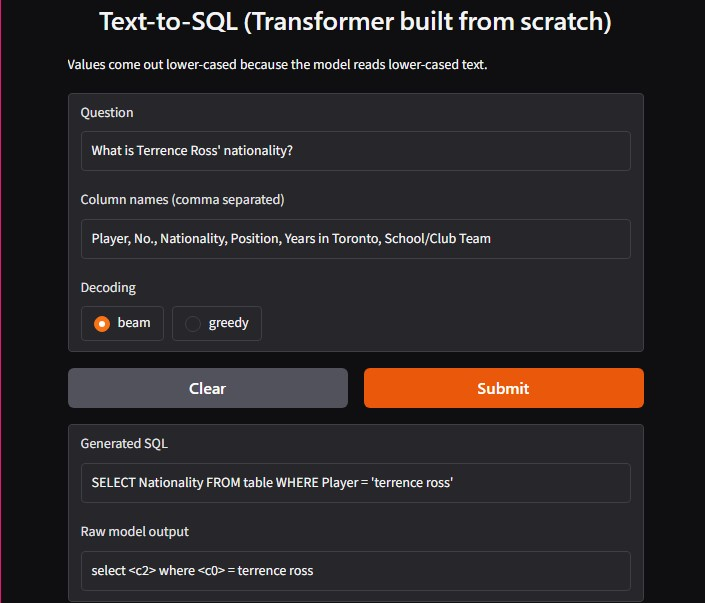

In [34]:
# screenshot of the front end (saved as results/frontend.png in the repo)
if os.path.exists("results/frontend.png"):
    display(Image("results/frontend.png"))
else:
    print("put the screenshot at results/frontend.png")

## Summary
| Split | Decoding | Logical form | Execution | Parse failures |
|---|---|---|---|---|
| Dev | greedy | 65.29% | 71.56% | 0.00% |
| Dev | beam (4) | 65.36% | 71.61% | 0.01% |
| Test | beam (4) | 65.05% | 71.39% | 0.09% |

7,577,600 trainable parameters, 20 epochs, 19.8 minutes on a Tesla T4, best epoch 18. Gold round-trip on dev: 100% execution.

**Limitations:** one training run only (no variance estimate, no hyper-parameter search); values are lower-cased by the starter code;
the attention check above is low and unexplained; beam vs greedy is not a meaningful difference on this data.